In [ ]:
!pip install --upgrade keras tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 52.6 MB/s eta 0:00:00
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.18.0
    Uninstalling tensorboard-2.18.0:
      Successfully uninstalled tensorboard-2.18.0
  Attempting uninstall: keras
    Found existing installation: keras 3.8.0
    Uninstalling keras-3.8.0:
      Successfully uninstalled keras-3.8.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.18.0
    Uninstalling tensorflow-2.18.0:
      Successfully uninstalled tensorflow-2.18.0
ERROR: pip's dependency resolve

In [ ]:
from keras.src.api_export import keras_export
from keras.src.layers.preprocessing.image_preprocessing.base_image_preprocessing_layer import (  # noqa: E501
    BaseImagePreprocessingLayer,
)
from keras.src.layers.preprocessing.image_preprocessing.bounding_boxes.converters import (  # noqa: E501
    clip_to_image_size,
)
from keras.src.layers.preprocessing.image_preprocessing.bounding_boxes.converters import (  # noqa: E501
    convert_format,
)
from keras.src.random.seed_generator import SeedGenerator
from keras.src.utils import backend_utils


@keras_export("keras.layers.RandomPerspective")
class RandomPerspective(BaseImagePreprocessingLayer):
    """A preprocessing layer that applies random perspective transformations.

    This layer distorts the perspective of input images by shifting their
    corner points, simulating a 3D-like transformation. The amount of distortion
    is controlled by the `factor` and `scale` parameters.

    Args:
        factor: A float or a tuple of two floats.
            Represents the probability of applying the perspective
            transformation to each image in the batch.
            - `factor=0.0` ensures no transformation is applied.
            - `factor=1.0` means the transformation is always applied.
            - If a tuple `(min, max)` is provided, a probability is randomly
              sampled between `min` and `max` for each image.
            - If a single float is given, the probability is sampled between
              `0.0` and the provided float.
            Default is 1.0.
        scale: A float defining the relative amount of perspective shift.
            Determines how much the image corners are displaced, affecting
            the intensity of the perspective effect.
        interpolation: Interpolation mode. Supported values: `"nearest"`,
            `"bilinear"`.
        fill_value: a float represents the value to be filled outside the
            boundaries when `fill_mode="constant"`.
        seed: Integer. Used to create a random seed.

    """

    _USE_BASE_FACTOR = False
    _FACTOR_BOUNDS = (0, 1)
    _SUPPORTED_INTERPOLATION = ("nearest", "bilinear")

    def __init__(
        self,
        factor=1.0,
        scale=1.0,
        interpolation="bilinear",
        fill_value=0.0,
        seed=None,
        data_format=None,
        **kwargs,
    ):
        super().__init__(data_format=data_format, **kwargs)
        self._set_factor(factor)
        self.scale = scale
        self.fill_value = fill_value
        self.interpolation = interpolation
        self.seed = seed
        self.generator = SeedGenerator(seed)
        self.supports_jit = False

        if scale < 0.0 or scale > 1.0:
            raise ValueError(
                "The `scale` argument should be a number "
                "in the range "
                f"[0,1]. "
                f"Received: scale={scale}"
            )

        if interpolation not in self._SUPPORTED_INTERPOLATION:
            raise NotImplementedError(
                f"Unknown `interpolation` {interpolation}. Expected of one "
                f"{self._SUPPORTED_INTERPOLATION}."
            )

        if self.data_format == "channels_first":
            self.height_axis = -2
            self.width_axis = -1
            self.channel_axis = -3
        else:
            self.height_axis = -3
            self.width_axis = -2
            self.channel_axis = -1

    def get_random_transformation(self, data, training=True, seed=None):
        if not training:
            return None

        if isinstance(data, dict):
            images = data["images"]
        else:
            images = data

        images_shape = self.backend.shape(images)
        unbatched = len(images_shape) == 3
        if unbatched:
            batch_size = 1
        else:
            batch_size = images_shape[0]
        height, width = (
            images.shape[self.height_axis],
            images.shape[self.width_axis],
        )

        seed = seed or self._get_seed_generator(self.backend._backend)

        transformation_probability = self.backend.random.uniform(
            shape=(batch_size,),
            minval=self.factor[0],
            maxval=self.factor[1],
            seed=seed,
        )

        random_threshold = self.backend.random.uniform(
            shape=(batch_size,),
            minval=0.0,
            maxval=1.0,
            seed=seed,
        )
        apply_perspective = random_threshold < transformation_probability

        perspective_factor = self.backend.random.uniform(
            shape=(batch_size, 4, 2),
            minval=-0.5 * self.scale,
            maxval=0.5 * self.scale,
            seed=seed,
            dtype=self.compute_dtype,
        )

        start_points = self.backend.convert_to_tensor(
            [
                [
                    [0.0, 0.0],
                    [width - 1, 0.0],
                    [0.0, height - 1],
                    [width - 1, height - 1],
                ]
            ],
            dtype=self.compute_dtype,
        )

        start_points = self.backend.numpy.repeat(
            start_points, batch_size, axis=0
        )
        end_points = start_points + start_points * perspective_factor

        return {
            "apply_perspective": apply_perspective,
            "start_points": start_points,
            "end_points": end_points,
            "input_shape": images_shape,
        }

    def transform_images(self, images, transformation, training=True):
        images = self.backend.cast(images, self.compute_dtype)
        if training and transformation is not None:
            images = self._perspective_inputs(images, transformation)
            images = self.backend.cast(images, self.compute_dtype)
        return images

    def _perspective_inputs(self, inputs, transformation):
        if transformation is None:
            return inputs

        inputs_shape = self.backend.shape(inputs)
        unbatched = len(inputs_shape) == 3
        if unbatched:
            inputs = self.backend.numpy.expand_dims(inputs, axis=0)

        start_points = transformation["start_points"]
        end_points = transformation["end_points"]

        outputs = self.backend.image.perspective_transform(
            inputs,
            start_points,
            end_points,
            interpolation=self.interpolation,
            fill_value=self.fill_value,
            data_format=self.data_format,
        )

        apply_perspective = transformation["apply_perspective"]
        outputs = self.backend.numpy.where(
            apply_perspective[:, None, None, None],
            outputs,
            inputs,
        )

        if unbatched:
            outputs = self.backend.numpy.squeeze(outputs, axis=0)
        return outputs

    def transform_bounding_boxes(
        self,
        bounding_boxes,
        transformation,
        training=True,
    ):
        if training and transformation is not None:
            if backend_utils.in_tf_graph():
                self.backend.set_backend("tensorflow")

            input_height, input_width = (
                transformation["input_shape"][self.height_axis],
                transformation["input_shape"][self.width_axis],
            )

            bounding_boxes = convert_format(
                bounding_boxes,
                source=self.bounding_box_format,
                target="xyxy",
                height=input_height,
                width=input_width,
            )

            boxes = bounding_boxes["boxes"]
            x0, y0, x1, y1 = self.backend.numpy.split(boxes, 4, axis=-1)

            start_points = transformation["start_points"]
            end_points = transformation["end_points"]
            transform = self.backend.image.compute_homography_matrix(
                start_points, end_points
            )
            transform = self.backend.numpy.expand_dims(transform, axis=1)
            transform = self.backend.cast(transform, dtype=self.compute_dtype)

            corners = [
                self._get_transformed_coordinates(x, y, transform)
                for x, y in [(x0, y0), (x1, y1), (x0, y1), (x1, y0)]
            ]
            x_corners, y_corners = zip(*corners)

            xs = self.backend.numpy.stack(x_corners, axis=-1)
            ys = self.backend.numpy.stack(y_corners, axis=-1)

            min_x, max_x = (
                self.backend.numpy.min(xs, axis=-1),
                self.backend.numpy.max(xs, axis=-1),
            )
            min_y, max_y = (
                self.backend.numpy.min(ys, axis=-1),
                self.backend.numpy.max(ys, axis=-1),
            )

            min_x = self.backend.numpy.expand_dims(min_x, axis=-1)
            max_x = self.backend.numpy.expand_dims(max_x, axis=-1)
            min_y = self.backend.numpy.expand_dims(min_y, axis=-1)
            max_y = self.backend.numpy.expand_dims(max_y, axis=-1)

            boxes = self.backend.numpy.concatenate(
                [min_x, min_y, max_x, max_y], axis=-1
            )

            apply_perspective = self.backend.core.convert_to_tensor(
                transformation["apply_perspective"], dtype=boxes.dtype
            )

            bounding_boxes["boxes"] = self.backend.numpy.where(
                apply_perspective[:, None, None],
                boxes,
                bounding_boxes["boxes"],
            )

            bounding_boxes = clip_to_image_size(
                bounding_boxes=bounding_boxes,
                height=input_height,
                width=input_width,
                bounding_box_format="xyxy",
            )

            self.backend.reset()

        return bounding_boxes

    def _get_transformed_coordinates(
        self, x_coords, y_coords, transformation_matrix
    ):
        backend = self.backend

        batch_size = backend.shape(transformation_matrix)[0]

        homogeneous_transform = backend.numpy.concatenate(
            [transformation_matrix, backend.numpy.ones((batch_size, 1, 1))],
            axis=-1,
        )
        homogeneous_transform = backend.numpy.reshape(
            homogeneous_transform, (batch_size, 3, 3)
        )

        inverse_transform = backend.linalg.inv(homogeneous_transform)

        ones_column = backend.numpy.ones_like(x_coords)
        homogeneous_coords = backend.numpy.concatenate(
            [x_coords, y_coords, ones_column], axis=-1
        )

        homogeneous_coords = backend.numpy.moveaxis(homogeneous_coords, -1, -2)
        transformed_coords = backend.numpy.matmul(
            inverse_transform, homogeneous_coords
        )
        transformed_coords = backend.numpy.moveaxis(transformed_coords, -1, -2)

        x_transformed = transformed_coords[..., 0] / transformed_coords[..., 2]
        y_transformed = transformed_coords[..., 1] / transformed_coords[..., 2]

        return x_transformed, y_transformed

    def transform_labels(self, labels, transformation, training=True):
        return labels

    def transform_segmentation_masks(
        self, segmentation_masks, transformation, training=True
    ):
        return self.transform_images(
            segmentation_masks, transformation, training=training
        )

    def compute_output_shape(self, input_shape):
        return input_shape

    def get_config(self):
        base_config = super().get_config()
        config = {
            "factor": self.factor,
            "scale": self.scale,
            "interpolation": self.interpolation,
            "fill_value": self.fill_value,
            "seed": self.seed,
        }
        return {**base_config, **config}

In [ ]:
from keras.src.api_export import keras_export
from keras.src.layers.preprocessing.image_preprocessing.base_image_preprocessing_layer import (  # noqa: E501
    BaseImagePreprocessingLayer,
)
from keras.src.random import SeedGenerator


@keras_export("keras.layers.RandomErasing")
class RandomErasing(BaseImagePreprocessingLayer):
    """Random Erasing data augmentation technique.

    Random Erasing is a data augmentation method where random patches of
    an image are erased (replaced by a constant value or noise)
    during training to improve generalization.

    Args:
        factor: A single float or a tuple of two floats.
            `factor` controls the probability of applying the transformation.
            - `factor=0.0` ensures no erasing is applied.
            - `factor=1.0` means erasing is always applied.
            - If a tuple `(min, max)` is provided, a probability value
              is sampled between `min` and `max` for each image.
            - If a single float is provided, a probability is sampled
              between `0.0` and the given float.
            Default is 1.0.
        scale: A tuple of two floats representing the aspect ratio range of
            the erased patch. This defines the width-to-height ratio of
            the patch to be erased. It can help control the rw shape of
            the erased region. Default is (0.02, 0.33).
        fill_value: A value to fill the erased region with. This can be set to
            a constant value or `None` to sample a random value
            from a normal distribution. Default is `None`.
        value_range: the range of values the incoming images will have.
            Represented as a two-number tuple written `[low, high]`. This is
            typically either `[0, 1]` or `[0, 255]` depending on how your
            preprocessing pipeline is set up.
        seed: Integer. Used to create a random seed.

    References:
       - [Random Erasing paper](https://arxiv.org/abs/1708.04896).
    """

    _USE_BASE_FACTOR = False
    _FACTOR_BOUNDS = (0, 1)

    def __init__(
        self,
        factor=1.0,
        scale=(0.02, 0.33),
        fill_value=None,
        value_range=(0, 255),
        seed=None,
        data_format=None,
        **kwargs,
    ):
        super().__init__(data_format=data_format, **kwargs)
        self._set_factor(factor)
        self.scale = self._set_factor_by_name(scale, "scale")
        self.fill_value = fill_value
        self.value_range = value_range
        self.seed = seed
        self.generator = SeedGenerator(seed)

        if self.data_format == "channels_first":
            self.height_axis = -2
            self.width_axis = -1
            self.channel_axis = -3
        else:
            self.height_axis = -3
            self.width_axis = -2
            self.channel_axis = -1

    def _set_factor_by_name(self, factor, name):
        error_msg = (
            f"The `{name}` argument should be a number "
            "(or a list of two numbers) "
            "in the range "
            f"[{self._FACTOR_BOUNDS[0]}, {self._FACTOR_BOUNDS[1]}]. "
            f"Received: factor={factor}"
        )
        if isinstance(factor, (tuple, list)):
            if len(factor) != 2:
                raise ValueError(error_msg)
            if (
                factor[0] > self._FACTOR_BOUNDS[1]
                or factor[1] < self._FACTOR_BOUNDS[0]
            ):
                raise ValueError(error_msg)
            lower, upper = sorted(factor)
        elif isinstance(factor, (int, float)):
            if (
                factor < self._FACTOR_BOUNDS[0]
                or factor > self._FACTOR_BOUNDS[1]
            ):
                raise ValueError(error_msg)
            factor = abs(factor)
            lower, upper = [max(-factor, self._FACTOR_BOUNDS[0]), factor]
        else:
            raise ValueError(error_msg)
        return lower, upper

    def _compute_crop_bounds(self, batch_size, image_length, crop_ratio, seed):
        crop_length = self.backend.cast(
            crop_ratio * image_length, dtype=self.compute_dtype
        )

        start_pos = self.backend.random.uniform(
            shape=[batch_size],
            minval=0,
            maxval=1,
            dtype=self.compute_dtype,
            seed=seed,
        ) * (image_length - crop_length)

        end_pos = start_pos + crop_length

        return start_pos, end_pos

    def _generate_batch_mask(self, images_shape, box_corners):
        def _generate_grid_xy(image_height, image_width):
            grid_y, grid_x = self.backend.numpy.meshgrid(
                self.backend.numpy.arange(
                    image_height, dtype=self.compute_dtype
                ),
                self.backend.numpy.arange(
                    image_width, dtype=self.compute_dtype
                ),
                indexing="ij",
            )
            if self.data_format == "channels_last":
                grid_y = self.backend.cast(
                    grid_y[None, :, :, None], dtype=self.compute_dtype
                )
                grid_x = self.backend.cast(
                    grid_x[None, :, :, None], dtype=self.compute_dtype
                )
            else:
                grid_y = self.backend.cast(
                    grid_y[None, None, :, :], dtype=self.compute_dtype
                )
                grid_x = self.backend.cast(
                    grid_x[None, None, :, :], dtype=self.compute_dtype
                )
            return grid_x, grid_y

        image_height, image_width = (
            images_shape[self.height_axis],
            images_shape[self.width_axis],
        )
        grid_x, grid_y = _generate_grid_xy(image_height, image_width)

        x0, x1, y0, y1 = box_corners

        x0 = x0[:, None, None, None]
        y0 = y0[:, None, None, None]
        x1 = x1[:, None, None, None]
        y1 = y1[:, None, None, None]

        batch_masks = (
            (grid_x >= x0) & (grid_x < x1) & (grid_y >= y0) & (grid_y < y1)
        )
        batch_masks = self.backend.numpy.repeat(
            batch_masks, images_shape[self.channel_axis], axis=self.channel_axis
        )

        return batch_masks

    def _get_fill_value(self, images, images_shape, seed):
        fill_value = self.fill_value
        if fill_value is None:
            fill_value = (
                self.backend.random.normal(
                    images_shape,
                    dtype=self.compute_dtype,
                    seed=seed,
                )
                * self.value_range[1]
            )
        else:
            error_msg = (
                "The `fill_value` argument should be a number "
                "(or a list of three numbers) "
            )
            if isinstance(fill_value, (tuple, list)):
                if len(fill_value) != 3:
                    raise ValueError(error_msg)
                fill_value = self.backend.numpy.full_like(
                    images, fill_value, dtype=self.compute_dtype
                )
            elif isinstance(fill_value, (int, float)):
                fill_value = (
                    self.backend.numpy.ones(
                        images_shape, dtype=self.compute_dtype
                    )
                    * fill_value
                )
            else:
                raise ValueError(error_msg)
        fill_value = self.backend.numpy.clip(
            fill_value, self.value_range[0], self.value_range[1]
        )
        return fill_value

    def get_random_transformation(self, data, training=True, seed=None):
        if not training:
            return None

        if isinstance(data, dict):
            images = data["images"]
        else:
            images = data

        images_shape = self.backend.shape(images)
        rank = len(images_shape)
        if rank == 3:
            batch_size = 1
        elif rank == 4:
            batch_size = images_shape[0]
        else:
            raise ValueError(
                "Expected the input image to be rank 3 or 4. Received "
                f"inputs.shape={images_shape}"
            )

        image_height = images_shape[self.height_axis]
        image_width = images_shape[self.width_axis]

        seed = seed or self._get_seed_generator(self.backend._backend)

        mix_weight = self.backend.random.uniform(
            shape=(batch_size, 2),
            minval=self.scale[0],
            maxval=self.scale[1],
            dtype=self.compute_dtype,
            seed=seed,
        )

        mix_weight = self.backend.numpy.sqrt(mix_weight)

        x0, x1 = self._compute_crop_bounds(
            batch_size, image_width, mix_weight[:, 0], seed
        )
        y0, y1 = self._compute_crop_bounds(
            batch_size, image_height, mix_weight[:, 1], seed
        )

        batch_masks = self._generate_batch_mask(
            images_shape,
            (x0, x1, y0, y1),
        )

        erase_probability = self.backend.random.uniform(
            shape=(batch_size,),
            minval=self.factor[0],
            maxval=self.factor[1],
            seed=seed,
        )

        random_threshold = self.backend.random.uniform(
            shape=(batch_size,),
            minval=0.0,
            maxval=1.0,
            seed=seed,
        )
        apply_erasing = random_threshold < erase_probability

        fill_value = self._get_fill_value(images, images_shape, seed)

        return {
            "apply_erasing": apply_erasing,
            "batch_masks": batch_masks,
            "fill_value": fill_value,
        }

    def transform_images(self, images, transformation=None, training=True):
        if training:
            images = self.backend.cast(images, self.compute_dtype)
            batch_masks = transformation["batch_masks"]
            apply_erasing = transformation["apply_erasing"]
            fill_value = transformation["fill_value"]

            erased_images = self.backend.numpy.where(
                batch_masks,
                fill_value,
                images,
            )

            images = self.backend.numpy.where(
                apply_erasing[:, None, None, None],
                erased_images,
                images,
            )

        images = self.backend.cast(images, self.compute_dtype)
        return images

    def transform_labels(self, labels, transformation, training=True):
        return labels

    def transform_bounding_boxes(
        self,
        bounding_boxes,
        transformation,
        training=True,
    ):
        return bounding_boxes

    def transform_segmentation_masks(
        self, segmentation_masks, transformation, training=True
    ):
        return segmentation_masks

    def compute_output_shape(self, input_shape):
        return input_shape

    def get_config(self):
        config = {
            "factor": self.factor,
            "scale": self.scale,
            "fill_value": self.fill_value,
            "value_range": self.value_range,
            "seed": self.seed,
        }
        base_config = super().get_config()
        return {**base_config, **config}

In [ ]:
import sys
assert sys.version_info >= (3, 5)

import tensorflow as tf
assert tf.__version__ >= "2.0"

import numpy as np
import os

from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)

import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

print('Python version: ', sys.version_info)
print('TF version: ', tf.__version__)
print('Keras version: ', keras.__version__)
print('GPU is', 'available' if tf.config.list_physical_devices('GPU') else 'NOT AVAILABLE')

Python version:  sys.version_info(major=3, minor=11, micro=12, releaselevel='final', serial=0)
TF version:  2.19.0
Keras version:  3.9.2
GPU is available


In [ ]:
#Todas as bibliotecas
import pathlib
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd
from tensorflow.keras.models import load_model
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


### Importar Datasets

Dataset 1

In [ ]:
data_dir = '/content/drive/MyDrive/Dataset 1'
dataset1 = os.listdir(data_dir)

print(dataset1)

['training_data', 'testing_data']


In [ ]:
IMG_SIZE = (160, 160)

data_dir_1 = pathlib.Path('/content/drive/MyDrive/Dataset 1')
test_dir_1 = os.path.join(str(data_dir_1), 'testing_data')
train_dir_1 = os.path.join(str(data_dir_1), 'training_data')

test_ds_1 = image_dataset_from_directory(test_dir_1, shuffle=True, seed=11, image_size=IMG_SIZE, color_mode='grayscale')

test_ds_1 = test_ds_1.cache().prefetch(1)

Found 325 files belonging to 2 classes.


In [ ]:
batch_size = 32
IMG_SIZE = (160, 160)

train_ds_1 = keras.preprocessing.image_dataset_from_directory(
    train_dir_1,
    validation_split=0.2,
    subset="training",
    seed=123,
    shuffle=True,
    image_size=IMG_SIZE,
    batch_size=batch_size,
    color_mode='grayscale'
)

val_ds_1 = keras.preprocessing.image_dataset_from_directory(
    train_dir_1,
    validation_split=0.2,
    subset="validation",
    seed=123,
    shuffle=True,
    image_size=IMG_SIZE,
    batch_size=batch_size,
    color_mode='grayscale'
)

class_names_1 = train_ds_1.class_names

train_ds_1 = train_ds_1.cache().prefetch(1)
val_ds_1 = val_ds_1.cache().prefetch(1)


Found 703 files belonging to 2 classes.
Using 563 files for training.
Found 703 files belonging to 2 classes.
Using 140 files for validation.


In [ ]:
print ( class_names_1)

['cracked', 'normal']


In [ ]:
count_normal = 0
count_cracked = 0

for images, labels in train_ds_1:
    labels = labels.numpy()
    count_cracked += np.sum(labels == class_names_1.index('cracked'))
    count_normal += np.sum(labels == class_names_1.index('normal'))


print(f'Normal: {count_normal}')
print(f'Cracked: {count_cracked}')

Normal: 302
Cracked: 261


In [ ]:
#Verificar a dimensão dos datasets criados

for image_batch, labels_batch in train_ds_1:
    print(image_batch.shape)
    print(labels_batch.shape)
    break

print('Class Names: ', class_names_1)

(32, 160, 160, 1)
(32,)
Class Names:  ['cracked', 'normal']


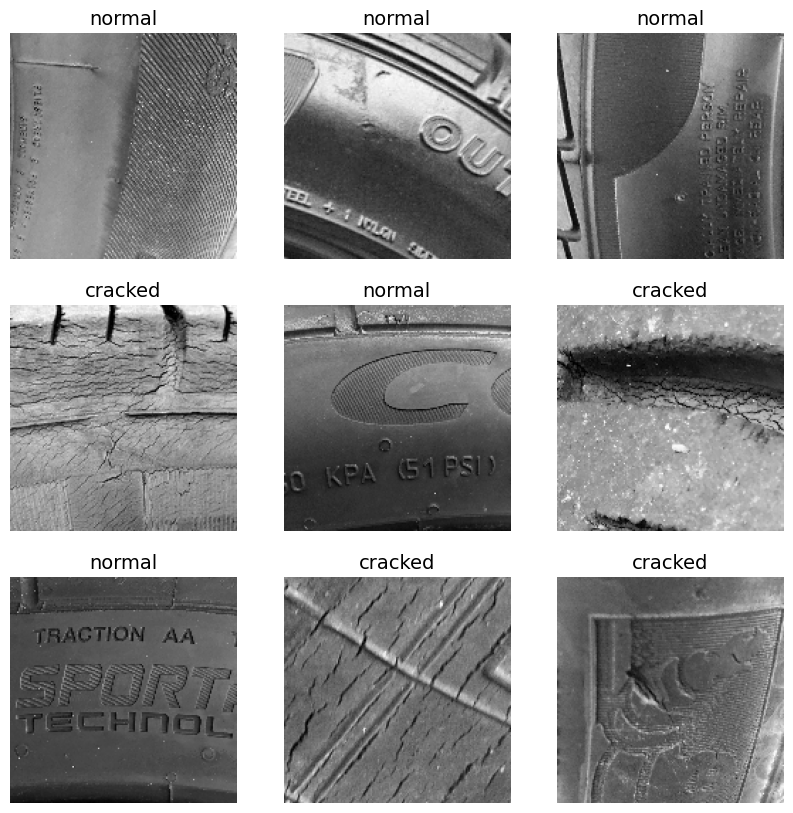

In [ ]:
import matplotlib.pyplot as plt

# Obter uma batch do dataset
for image_batch, labels_batch in train_ds_1:
    # Mostrar 9 imagens da batch
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"), cmap='gray') #cmap='gray' pq o imshow aplica por padrão o mapa de padrão viridis
        plt.title(class_names_1[labels_batch[i]])
        plt.axis("off")
    break  # Só queremos a primeira batch

Dataset 2

In [ ]:
data_dir = '/content/drive/MyDrive/Dataset 2'
dataset2 = os.listdir(data_dir)

print(dataset2)

['cracked', 'normal']


In [ ]:
IMG_SIZE = (160, 160)

data_dir_2 = pathlib.Path('/content/drive/MyDrive/Dataset 2')
test_dir_2 = os.path.join(str(data_dir_2), 'testing_data')
train_dir_2 = os.path.join(str(data_dir_2), 'training_data')

test_ds_2 = image_dataset_from_directory(test_dir_2, shuffle=True, seed=11, image_size=IMG_SIZE, color_mode='grayscale')

test_ds_2 = test_ds_2.cache().prefetch(1)

In [ ]:
#Verificar a dimensão dos datasets criados

for image_batch, labels_batch in train_ds_2:
    print(image_batch.shape)
    print(labels_batch.shape)
    break

print('Class Names: ', class_names_2)

(32, 160, 160, 1)
(32,)
Class Names:  ['cracked', 'normal']


Dataset 3

In [ ]:
data_dir = '/content/drive/MyDrive/Dataset 3'
dataset3 = os.listdir(data_dir)

print(dataset3)

['cracked', 'normal']


In [ ]:
IMG_SIZE = (160, 160)

data_dir_3 = pathlib.Path('/content/drive/MyDrive/Dataset 3')
test_dir_3 = os.path.join(str(data_dir_3), 'testing_data')
train_dir_3 = os.path.join(str(data_dir_3), 'training_data')

test_ds_3 = image_dataset_from_directory(test_dir_3, shuffle=True, seed=11, image_size=IMG_SIZE, color_mode='grayscale')

test_ds_3 = test_ds_3.cache().prefetch(1)

In [ ]:
#Verificar a dimensão dos datasets criados

for image_batch, labels_batch in train_ds_3:
    print(image_batch.shape)
    print(labels_batch.shape)
    break

print('Class Names: ', class_names_3)

(32, 160, 160, 1)
(32,)
Class Names:  ['cracked', 'normal']


### CNN

In [ ]:
model_CNN = keras.Sequential([
    layers.Input(shape=(160,160,1)),
    layers.Rescaling(1./255),
    layers.Conv2D(32, 3, activation= 'relu', padding='same'),
    layers.Conv2D(32, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation= 'relu'),
    layers.Dense(1, activation= 'sigmoid')])

In [ ]:
model_CNN.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 160, 160, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 160, 160, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 40, 40, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 10, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       204,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491,361 (1.87 MB)

 Trainable params: 491,361 (1.87 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 137ms/step - accuracy: 0.7412 - loss: 0.5337 - val_accuracy: 0.7571 - val_loss: 0.5196
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.7457 - loss: 0.5319 - val_accuracy: 0.7571 - val_loss: 0.5202
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.7527 - loss: 0.5286 - val_accuracy: 0.7500 - val_loss: 0.5198
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.7540 - loss: 0.5270 - val_accuracy: 0.7500 - val_loss: 0.5204
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.7562 - loss: 0.5251 - val_accuracy: 0.7500 - val_loss: 0.5212
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.7566 - loss: 0.5231 - val_accuracy: 0.7429 - val_loss: 0.5222
Epoch 7/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.7550 - loss: 0.5212 - val_accuracy: 0.7500 - val_loss: 0.5235
Epoch 8/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.7538 - loss: 0.5157 - val_accuracy: 0.7500 - 

<Axes: >

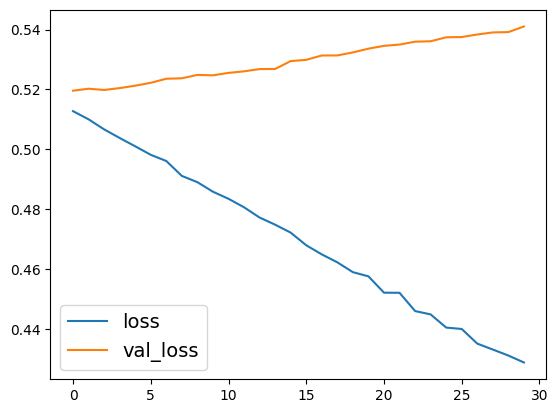

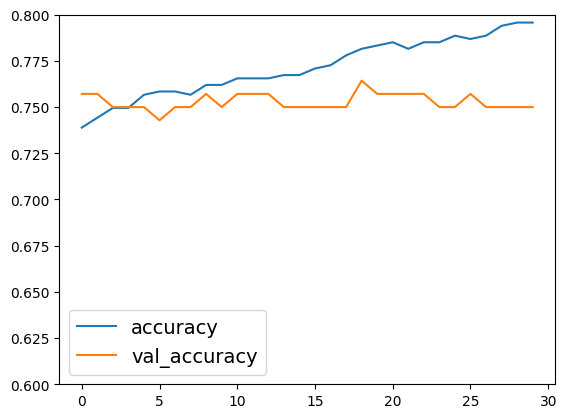

In [ ]:
#Compilação + loss function + melhor modelo

lossCNN = "binary_crossentropy"

model_CNN.compile(loss=lossCNN,
                  optimizer=keras.optimizers.SGD(),
                  metrics=['accuracy'])

checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max')

history = model_CNN.fit(train_ds_1, epochs=30, validation_data = val_ds_1, callbacks=[checkpoint])


#Gráficos de evolução
history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['accuracy', 'val_accuracy']].plot(ylim=(0.60,0.80))

11/11 ━━━━━━━━━━━━━━━━━━━━ 150s 13s/step
325 325
Accuracy - Dataset 1: 0.7200


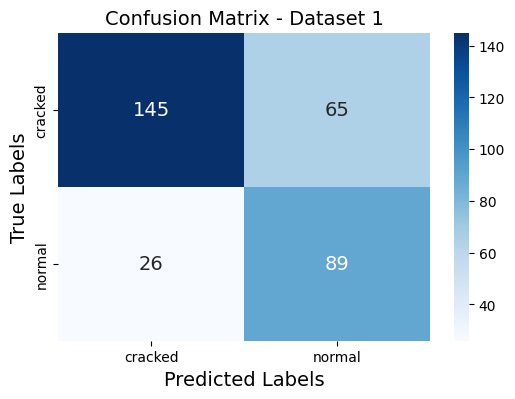

In [ ]:
model = keras.models.load_model('best_model.keras')

predictions = model.predict(test_ds_1)
y_pred = np.where(predictions> 0.5, 1, 0)

y_pred_classes = (predictions > 0.5).astype(int)  # Para classificação binária

# True labels para test_ds
y_true = np.concatenate([y for x, y in test_ds_1], axis=0)

y_pred_classes = y_pred_classes.flatten()

print(len(y_true), len(y_pred_classes))

# Accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f'Accuracy - Dataset 1: {accuracy:.4f}')

confusion_matrix_1 = confusion_matrix(y_true,y_pred)
plt.figure (figsize = (6, 4))
sns.heatmap(confusion_matrix_1, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_1, yticklabels=class_names_1)
plt.title('Confusion Matrix - Dataset 1')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

## Data Augmentation - Brightness

In [ ]:
data_augmentation = keras.Sequential(
    [
        layers.RandomBrightness(0.01)
    ]
 )

In [ ]:
model_CNN = keras.Sequential([
    layers.Input(shape=(160,160,1)),
    layers.Rescaling(1./255),
    data_augmentation,
    layers.Conv2D(32, 3, activation= 'relu', padding='same'),
    layers.Conv2D(32, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation= 'relu'),
    layers.Dense(1, activation= 'sigmoid')])

In [ ]:
model_CNN.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 160, 160, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 160, 160, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 160, 160, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 160, 160, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 40, 40, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 10, 10, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       204,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491,361 (1.87 MB)

 Trainable params: 491,361 (1.87 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 155ms/step - accuracy: 0.5450 - loss: 0.6863 - val_accuracy: 0.5571 - val_loss: 0.6750
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.5504 - loss: 0.6864 - val_accuracy: 0.6643 - val_loss: 0.6732
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.5761 - loss: 0.6820 - val_accuracy: 0.5357 - val_loss: 0.6761
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.5648 - loss: 0.6892 - val_accuracy: 0.6643 - val_loss: 0.6726
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5569 - loss: 0.6852 - val_accuracy: 0.5571 - val_loss: 0.6740
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5357 - loss: 0.6869 - val_accuracy: 0.6071 - val_loss: 0.6726
Epoch 7/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.5697 - loss: 0.6850 - val_accuracy: 0.6286 - val_loss: 0.6727
Epoch 8/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5342 - loss: 0.6898 - val_accuracy: 0.5500 - 

<Axes: >

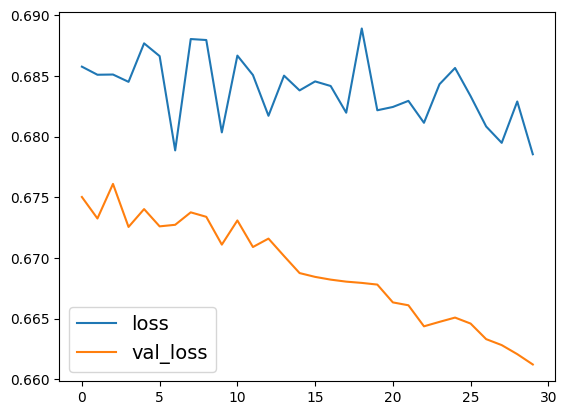

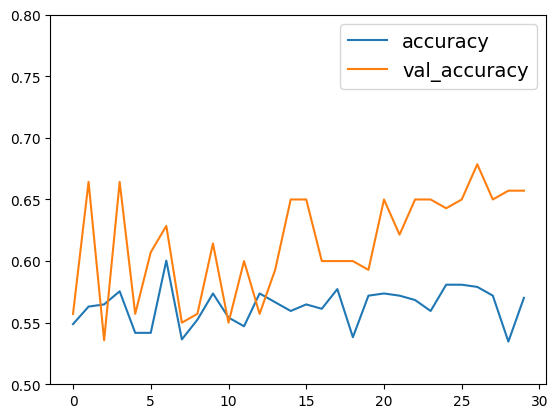

In [ ]:
#Compilação + loss function + melhor modelo

lossCNN = "binary_crossentropy"

model_CNN.compile(loss=lossCNN,
                  optimizer=keras.optimizers.SGD(),
                  metrics=['accuracy'])

checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max')

history = model_CNN.fit(train_ds_1, epochs=30, validation_data = val_ds_1, callbacks=[checkpoint])


#Gráficos de evolução
history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['accuracy', 'val_accuracy']].plot(ylim=(0.50,0.80))

In [ ]:
model = keras.models.load_model('best_model.keras')

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step
325 325
Accuracy - Dataset 1: 0.4831


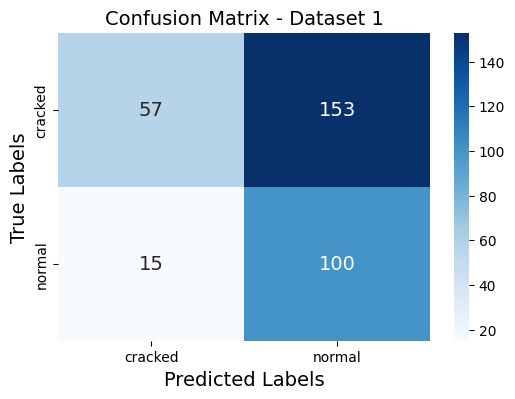

In [ ]:
predictions = model.predict(test_ds_1)
y_pred = np.where(predictions> 0.5, 1, 0)

y_pred_classes = (predictions > 0.5).astype(int)  # Para classificação binária

# True labels para test_ds
y_true = np.concatenate([y for x, y in test_ds_1], axis=0)

y_pred_classes = y_pred_classes.flatten()

print(len(y_true), len(y_pred_classes))

# Accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f'Accuracy - Dataset 1: {accuracy:.4f}')

confusion_matrix_2 = confusion_matrix(y_true,y_pred)
plt.figure (figsize = (6, 4))
sns.heatmap(confusion_matrix_2, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_1, yticklabels=class_names_1)
plt.title('Confusion Matrix - Dataset 1')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

## Data Augmentation - Zoom

In [ ]:
data_augmentation = keras.Sequential(
    [
        layers.RandomZoom(height_factor=(-0.2, 0.2), width_factor=(-0.2, 0.2))
    ]
 )

In [ ]:
model_CNN = keras.Sequential([
    layers.Input(shape=(160,160,1)),
    layers.Rescaling(1./255),
    data_augmentation,
    layers.Conv2D(32, 3, activation= 'relu', padding='same'),
    layers.Conv2D(32, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation= 'relu'),
    layers.Dense(1, activation= 'sigmoid')])

model_CNN.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 160, 160, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 160, 160, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 160, 160, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 160, 160, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 40, 40, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 10, 10, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       204,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491,361 (1.87 MB)

 Trainable params: 491,361 (1.87 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.6070 - loss: 0.6697 - val_accuracy: 0.5214 - val_loss: 0.6778
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.5948 - loss: 0.6692 - val_accuracy: 0.5214 - val_loss: 0.6770
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.6073 - loss: 0.6678 - val_accuracy: 0.5214 - val_loss: 0.6763
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.5967 - loss: 0.6667 - val_accuracy: 0.5286 - val_loss: 0.6755
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.5840 - loss: 0.6662 - val_accuracy: 0.5357 - val_loss: 0.6746
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.6005 - loss: 0.6652 - val_accuracy: 0.5357 - val_loss: 0.6735
Epoch 7/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.6003 - loss: 0.6640 - val_accuracy: 0.5357 - val_loss: 0.6725
Epoch 8/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.6029 - loss: 0.6634 - val_accuracy: 0.5357 - v

<Axes: >

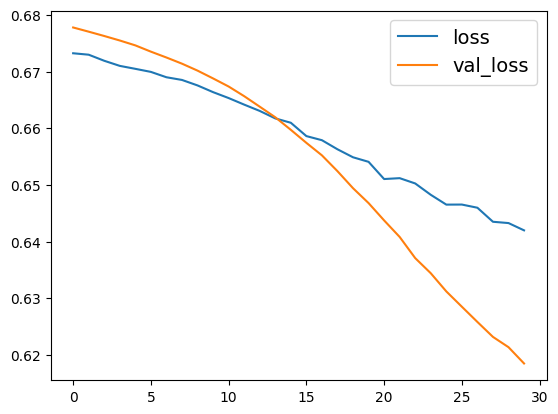

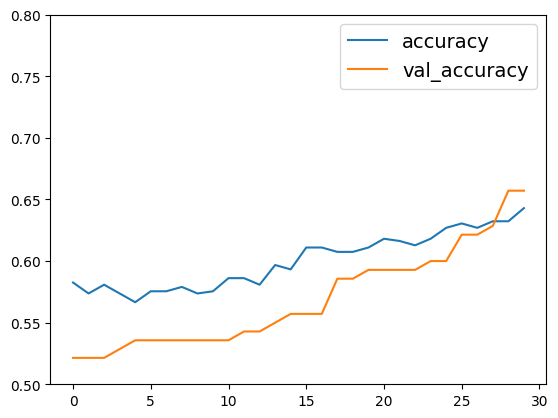

In [ ]:
#Compilação + loss function + melhor modelo

lossCNN = "binary_crossentropy"

model_CNN.compile(loss=lossCNN,
                  optimizer=keras.optimizers.SGD(),
                  metrics=['accuracy'])

checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max')

history = model_CNN.fit(train_ds_1, epochs=30, validation_data = val_ds_1, callbacks=[checkpoint])


#Gráficos de evolução
history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['accuracy', 'val_accuracy']].plot(ylim=(0.50,0.80))

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
325 325
Accuracy - Dataset 1: 0.5354


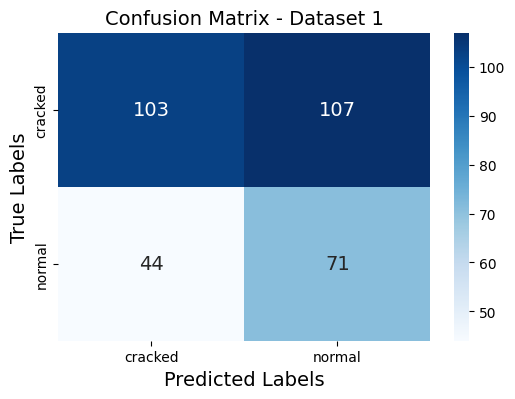

In [ ]:
model = keras.models.load_model('best_model.keras')

predictions = model.predict(test_ds_1)
y_pred = np.where(predictions> 0.5, 1, 0)

y_pred_classes = (predictions > 0.5).astype(int)  # Para classificação binária

# True labels para test_ds
y_true = np.concatenate([y for x, y in test_ds_1], axis=0)

y_pred_classes = y_pred_classes.flatten()

print(len(y_true), len(y_pred_classes))

# Accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f'Accuracy - Dataset 1: {accuracy:.4f}')

confusion_matrix_3 = confusion_matrix(y_true,y_pred)
plt.figure (figsize = (6, 4))
sns.heatmap(confusion_matrix_3, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_1, yticklabels=class_names_1)
plt.title('Confusion Matrix - Dataset 1')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

## Data Augmentation - Perspective

In [ ]:
random_perspective = RandomPerspective(
    factor=0.5,
    scale=0.2,
    interpolation="bilinear",
    fill_value=0.0,
    seed=42
)

In [ ]:
model_CNN = keras.Sequential([
    layers.Input(shape=(160,160,1)),
    layers.Rescaling(1./255),
    random_perspective,
    layers.Conv2D(32, 3, activation= 'relu', padding='same'),
    layers.Conv2D(32, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation= 'relu'),
    layers.Dense(1, activation= 'sigmoid')])

model_CNN.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 160, 160, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_perspective              │ (None, 160, 160, 1)    │             0 │
│ (RandomPerspective)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 160, 160, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 40, 40, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 10, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       204,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491,361 (1.87 MB)

 Trainable params: 491,361 (1.87 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.6598 - loss: 0.6311 - val_accuracy: 0.6214 - val_loss: 0.6207
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.6586 - loss: 0.6291 - val_accuracy: 0.6143 - val_loss: 0.6183
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.6581 - loss: 0.6297 - val_accuracy: 0.6214 - val_loss: 0.6164
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.6586 - loss: 0.6309 - val_accuracy: 0.6214 - val_loss: 0.6146
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.6601 - loss: 0.6288 - val_accuracy: 0.6286 - val_loss: 0.6127
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.6595 - loss: 0.6275 - val_accuracy: 0.6286 - val_loss: 0.6106
Epoch 7/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.6623 - loss: 0.6284 - val_accuracy: 0.6286 - val_loss: 0.6101
Epoch 8/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.6640 - loss: 0.6275 - val_accuracy: 0.6429 - v

<Axes: >

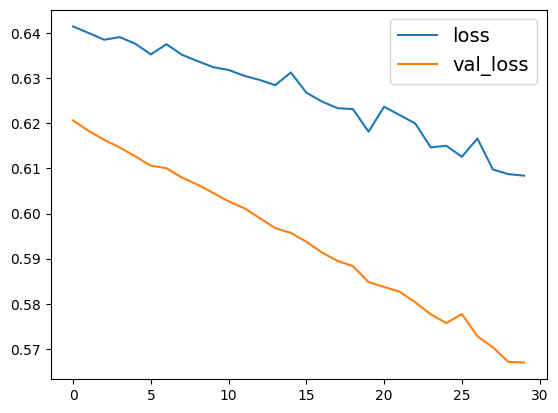

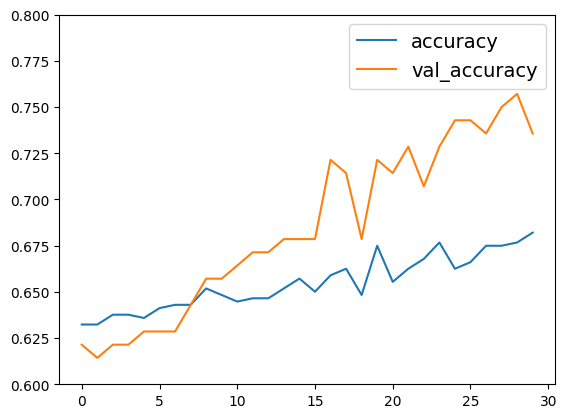

In [ ]:
#Compilação + loss function + melhor modelo

lossCNN = "binary_crossentropy"

model_CNN.compile(loss=lossCNN,
                  optimizer=keras.optimizers.SGD(),
                  metrics=['accuracy'])

checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max')

history = model_CNN.fit(train_ds_1, epochs=30, validation_data = val_ds_1, callbacks=[checkpoint])


#Gráficos de evolução
history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['accuracy', 'val_accuracy']].plot(ylim=(0.60,0.80))

11/11 ━━━━━━━━━━━━━━━━━━━━ 141s 13s/step
325 325
Accuracy - Dataset 1: 0.5877


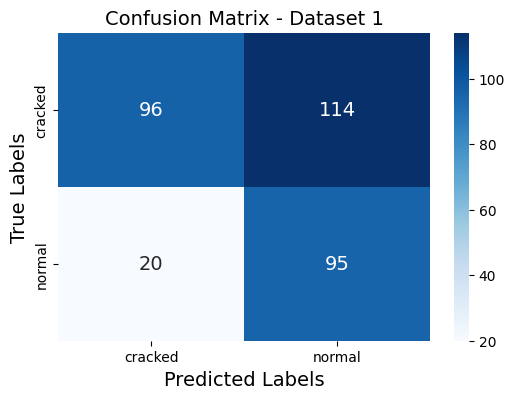

In [ ]:
model = keras.models.load_model('best_model.keras')

predictions = model.predict(test_ds_1)
y_pred = np.where(predictions> 0.5, 1, 0)

y_pred_classes = (predictions > 0.5).astype(int)  # Para classificação binária

# True labels para test_ds
y_true = np.concatenate([y for x, y in test_ds_1], axis=0)

y_pred_classes = y_pred_classes.flatten()

print(len(y_true), len(y_pred_classes))

# Accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f'Accuracy - Dataset 1: {accuracy:.4f}')

confusion_matrix_4 = confusion_matrix(y_true,y_pred)
plt.figure (figsize = (6, 4))
sns.heatmap(confusion_matrix_4, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_1, yticklabels=class_names_1)
plt.title('Confusion Matrix - Dataset 1')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

## Data Augmentation - Erasing

In [ ]:
random_erasing = RandomErasing(
    factor=0.6,
    scale=(0.02, 0.33),
    fill_value=None,
    value_range=(0, 255),
    seed=42
)

In [ ]:
model_CNN = keras.Sequential([
    layers.Input(shape=(160,160,1)),
    layers.Rescaling(1./255),
    random_erasing,
    layers.Conv2D(32, 3, activation= 'relu', padding='same'),
    layers.Conv2D(32, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation= 'relu'),
    layers.Dense(1, activation= 'sigmoid')])

model_CNN.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ (None, 160, 160, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_erasing (RandomErasing)  │ (None, 160, 160, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 160, 160, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 160, 160, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 40, 40, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 10, 10, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │       204,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491,361 (1.87 MB)

 Trainable params: 491,361 (1.87 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 297ms/step - accuracy: 0.5869 - loss: 0.6858 - val_accuracy: 0.4929 - val_loss: 0.6801
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.5672 - loss: 0.6706 - val_accuracy: 0.5000 - val_loss: 0.6775
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.5707 - loss: 0.6783 - val_accuracy: 0.5143 - val_loss: 0.6770
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.5746 - loss: 0.6793 - val_accuracy: 0.5214 - val_loss: 0.6767
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5902 - loss: 0.6759 - val_accuracy: 0.4929 - val_loss: 0.6787
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5894 - loss: 0.6711 - val_accuracy: 0.5000 - val_loss: 0.6782
Epoch 7/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.5362 - loss: 0.6772 - val_accuracy: 0.5143 - val_loss: 0.6764
Epoch 8/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.5775 - loss: 0.6785 - val_accuracy: 0.5571 -

<Axes: >

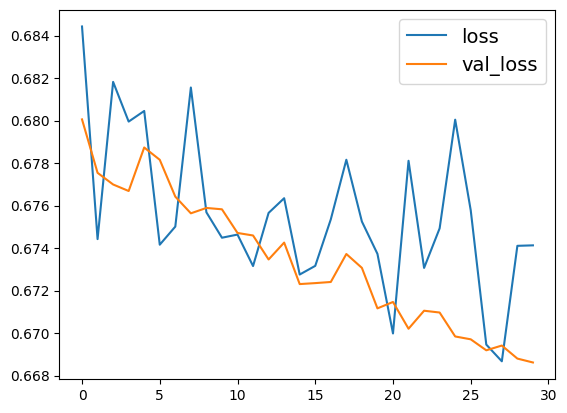

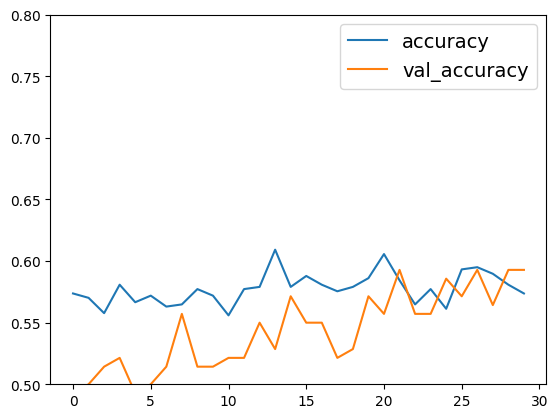

In [ ]:
#Compilação + loss function + melhor modelo

lossCNN = "binary_crossentropy"

model_CNN.compile(loss=lossCNN,
                  optimizer=keras.optimizers.SGD(),
                  metrics=['accuracy'])

checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max')

history = model_CNN.fit(train_ds_1, epochs=30, validation_data = val_ds_1, callbacks=[checkpoint])


#Gráficos de evolução
history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['accuracy', 'val_accuracy']].plot(ylim=(0.50,0.80))

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step
325 325
Accuracy - Dataset 1: 0.6338


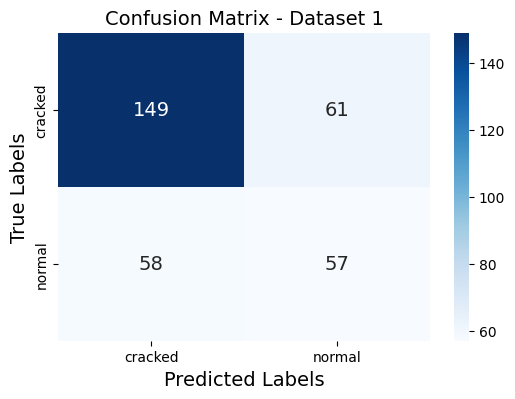

In [ ]:
model = keras.models.load_model('best_model.keras')

predictions = model.predict(test_ds_1)
y_pred = np.where(predictions> 0.5, 1, 0)

y_pred_classes = (predictions > 0.5).astype(int)  # Para classificação binária

# True labels para test_ds
y_true = np.concatenate([y for x, y in test_ds_1], axis=0)

y_pred_classes = y_pred_classes.flatten()

print(len(y_true), len(y_pred_classes))

# Accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f'Accuracy - Dataset 1: {accuracy:.4f}')

confusion_matrix_5 = confusion_matrix(y_true,y_pred)
plt.figure (figsize = (6, 4))
sns.heatmap(confusion_matrix_5, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_1, yticklabels=class_names_1)
plt.title('Confusion Matrix - Dataset 1')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

## com Dropout

In [ ]:
model_CNN = keras.Sequential([
    layers.Input(shape=(160,160,1)),
    layers.Rescaling(1./255),
    layers.Conv2D(32, 3, activation= 'relu', padding='same'),
    layers.Conv2D(32, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(64, activation= 'relu'),
    layers.Dense(1, activation= 'sigmoid')])

In [ ]:
model_CNN.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_5 (Rescaling)         │ (None, 160, 160, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 160, 160, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 160, 160, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 40, 40, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 10, 10, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │       204,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491,361 (1.87 MB)

 Trainable params: 491,361 (1.87 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 166ms/step - accuracy: 0.6295 - loss: 0.6227 - val_accuracy: 0.6500 - val_loss: 0.6195
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.6553 - loss: 0.6170 - val_accuracy: 0.6500 - val_loss: 0.6172
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.6521 - loss: 0.6208 - val_accuracy: 0.6571 - val_loss: 0.6145
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.6695 - loss: 0.6174 - val_accuracy: 0.6643 - val_loss: 0.6114
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.6574 - loss: 0.6141 - val_accuracy: 0.6857 - val_loss: 0.6090
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.6596 - loss: 0.6145 - val_accuracy: 0.7000 - val_loss: 0.6040
Epoch 7/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.6669 - loss: 0.6097 - val_accuracy: 0.7000 - val_loss: 0.6011
Epoch 8/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.6699 - loss: 0.6104 - val_accuracy: 0.7214 - 

<Axes: >

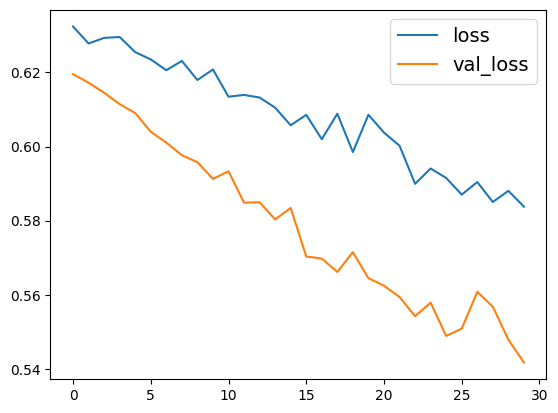

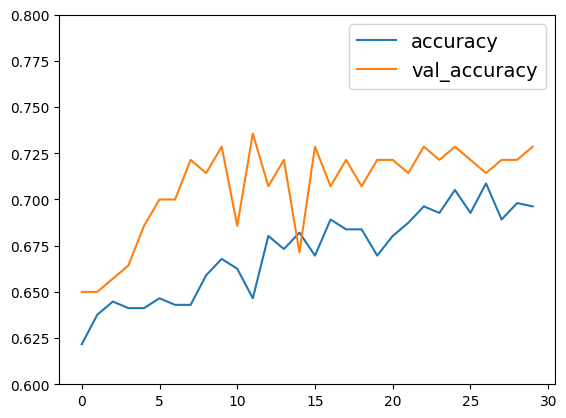

In [ ]:
#Compilação + loss function + melhor modelo

lossCNN = "binary_crossentropy"

model_CNN.compile(loss=lossCNN,
                  optimizer=keras.optimizers.SGD(),
                  metrics=['accuracy'])

checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max')

history = model_CNN.fit(train_ds_1, epochs=30, validation_data= val_ds_1, callbacks=[checkpoint])


#Gráficos de evolução
history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['accuracy', 'val_accuracy']].plot(ylim=(0.60,0.80))

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
325 325
Accuracy - Dataset 1: 0.5569


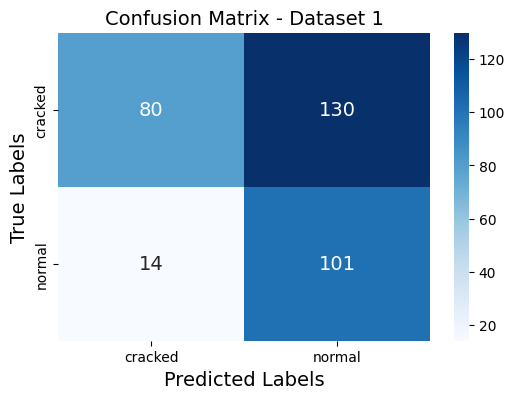

In [ ]:
model = keras.models.load_model('best_model.keras')

predictions = model.predict(test_ds_1)
y_pred = np.where(predictions> 0.5, 1, 0)

y_pred_classes = (predictions > 0.5).astype(int)  # Para classificação binária

# True labels para test_ds
y_true = np.concatenate([y for x, y in test_ds_1], axis=0)

y_pred_classes = y_pred_classes.flatten()

print(len(y_true), len(y_pred_classes))

# Accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f'Accuracy - Dataset 1: {accuracy:.4f}')

confusion_matrix_6 = confusion_matrix(y_true,y_pred)
plt.figure (figsize = (6, 4))
sns.heatmap(confusion_matrix_6, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_1, yticklabels=class_names_1)
plt.title('Confusion Matrix - Dataset 1')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

## com Random Perspective + Dropout

In [ ]:
#melhor camada de data augmentation

In [ ]:
model_CNN = keras.Sequential([
    layers.Input(shape=(160,160,1)),
    layers.Rescaling(1./255),
    random_perspective,
    layers.Conv2D(32, 3, activation= 'relu', padding='same'),
    layers.Conv2D(32, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(64, activation= 'relu'),
    layers.Dense(1, activation= 'sigmoid')])

In [ ]:
model_CNN.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 160, 160, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_perspective              │ (None, 160, 160, 1)    │             0 │
│ (RandomPerspective)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 160, 160, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 160, 160, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 40, 40, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 10, 10, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       204,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491,361 (1.87 MB)

 Trainable params: 491,361 (1.87 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.6543 - loss: 0.6271 - val_accuracy: 0.6643 - val_loss: 0.5951
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.6635 - loss: 0.6140 - val_accuracy: 0.6786 - val_loss: 0.5915
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.6621 - loss: 0.6295 - val_accuracy: 0.6643 - val_loss: 0.5891
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.6842 - loss: 0.6166 - val_accuracy: 0.6786 - val_loss: 0.5880
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.6478 - loss: 0.6207 - val_accuracy: 0.6714 - val_loss: 0.5848
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.6553 - loss: 0.6221 - val_accuracy: 0.6786 - val_loss: 0.5861
Epoch 7/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.6727 - loss: 0.6264 - val_accuracy: 0.6786 - val_loss: 0.5859
Epoch 8/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.6940 - loss: 0.6151 - val_accuracy: 0.7214 - v

<Axes: >

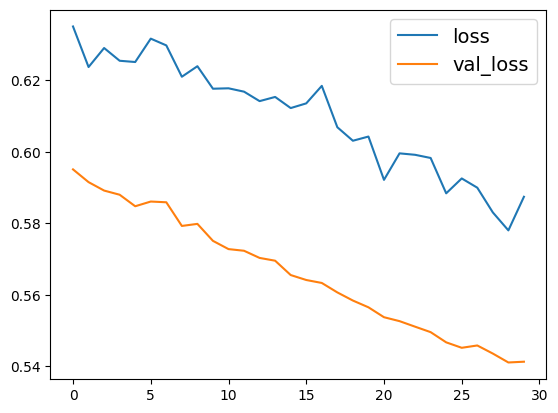

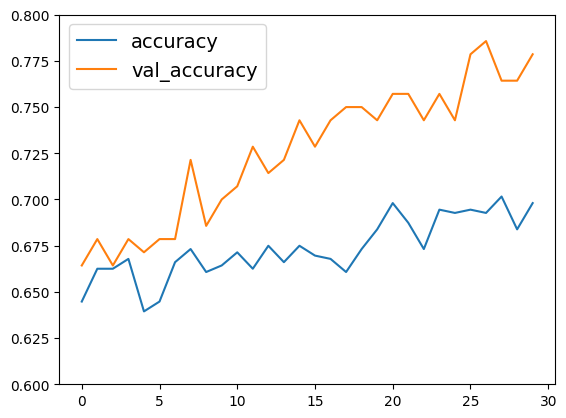

In [ ]:
#Compilação + loss function + melhor modelo

lossCNN = "binary_crossentropy"

model_CNN.compile(loss=lossCNN,
                  optimizer=keras.optimizers.SGD(),
                  metrics=['accuracy'])

checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max')

history = model_CNN.fit(train_ds_1, epochs=30, validation_data= val_ds_1, callbacks=[checkpoint])


#Gráficos de evolução
history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['accuracy', 'val_accuracy']].plot(ylim=(0.60,0.80))

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
325 325
Accuracy - Dataset 1: 0.6615


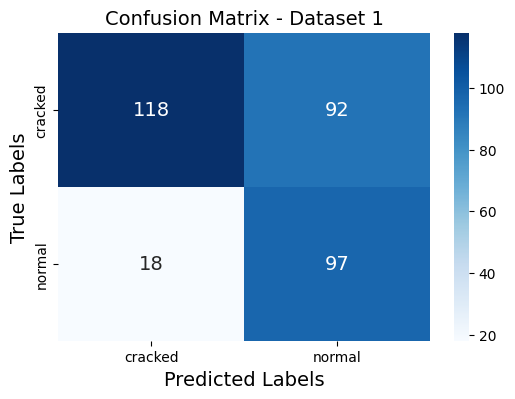

In [ ]:
model = keras.models.load_model('best_model.keras')

predictions = model.predict(test_ds_1)
y_pred = np.where(predictions> 0.5, 1, 0)

y_pred_classes = (predictions > 0.5).astype(int)  # Para classificação binária

# True labels para test_ds
y_true = np.concatenate([y for x, y in test_ds_1], axis=0)

y_pred_classes = y_pred_classes.flatten()

print(len(y_true), len(y_pred_classes))

# Accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f'Accuracy - Dataset 1: {accuracy:.4f}')

confusion_matrix_7 = confusion_matrix(y_true,y_pred)
plt.figure (figsize = (6, 4))
sns.heatmap(confusion_matrix_7, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_1, yticklabels=class_names_1)
plt.title('Confusion Matrix - Dataset 1')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

## Random Erasing + Dropout


In [ ]:
model_CNN = keras.Sequential([
    layers.Input(shape=(160,160,1)),
    layers.Rescaling(1./255),
    random_erasing,
    layers.Conv2D(32, 3, activation= 'relu', padding='same'),
    layers.Conv2D(32, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(64, activation= 'relu'),
    layers.Dense(1, activation= 'sigmoid')])

model_CNN.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 160, 160, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_erasing (RandomErasing)  │ (None, 160, 160, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 160, 160, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 160, 160, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 40, 40, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 10, 10, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       204,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491,361 (1.87 MB)

 Trainable params: 491,361 (1.87 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 392ms/step - accuracy: 0.5277 - loss: 0.6882 - val_accuracy: 0.5286 - val_loss: 0.6893
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.5303 - loss: 0.6891 - val_accuracy: 0.5286 - val_loss: 0.6892
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.5348 - loss: 0.6879 - val_accuracy: 0.5286 - val_loss: 0.6893
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.5268 - loss: 0.6890 - val_accuracy: 0.5286 - val_loss: 0.6892
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.5313 - loss: 0.6909 - val_accuracy: 0.5286 - val_loss: 0.6892
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.5252 - loss: 0.6895 - val_accuracy: 0.5286 - val_loss: 0.6892
Epoch 7/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.5178 - loss: 0.6889 - val_accuracy: 0.5286 - val_loss: 0.6890
Epoch 8/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.5278 - loss: 0.6908 - val_accuracy: 0.5286 -

<Axes: >

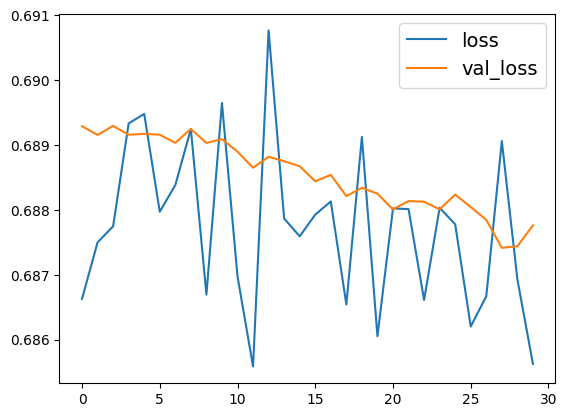

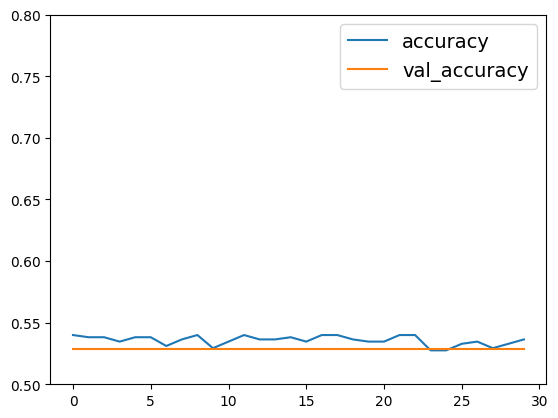

In [ ]:
#Compilação + loss function + melhor modelo

lossCNN = "binary_crossentropy"

model_CNN.compile(loss=lossCNN,
                  optimizer=keras.optimizers.SGD(),
                  metrics=['accuracy'])

checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max')

history = model_CNN.fit(train_ds_1, epochs=30, validation_data= val_ds_1, callbacks=[checkpoint])


#Gráficos de evolução
history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['accuracy', 'val_accuracy']].plot(ylim=(0.50,0.80))

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step
325 325
Accuracy - Dataset 1: 0.3538


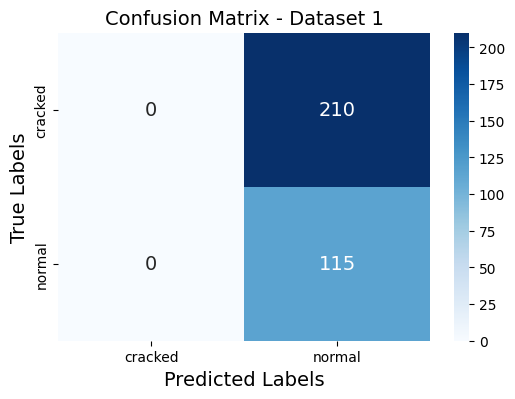

In [ ]:
model = keras.models.load_model('best_model.keras')

predictions = model.predict(test_ds_1)
y_pred = np.where(predictions> 0.5, 1, 0)

y_pred_classes = (predictions > 0.5).astype(int)  # Para classificação binária

# True labels para test_ds
y_true = np.concatenate([y for x, y in test_ds_1], axis=0)

y_pred_classes = y_pred_classes.flatten()

print(len(y_true), len(y_pred_classes))

# Accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f'Accuracy - Dataset 1: {accuracy:.4f}')

confusion_matrix_8 = confusion_matrix(y_true,y_pred)
plt.figure (figsize = (6, 4))
sns.heatmap(confusion_matrix_8, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_1, yticklabels=class_names_1)
plt.title('Confusion Matrix - Dataset 1')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()